# Copy-Paste Augmentation Analysis

Simple analysis comparing original dataset vs augmented dataset.

**Analysis includes:**
- Image counts comparison
- Object size distribution (small, medium, large)
- Object difficulty scores
- Image-level difficulty comparison

In [6]:
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ============ CONFIGURATION ============
PROJECT_ROOT = Path("/home/khanh/Projects/DifficultyAgri")

# Paths to datasets
INITIAL_DATA_PATH = PROJECT_ROOT / "datasets" / "minneapple" / "yolo_format" / "minneapple_yolo" / "train"
AUGMENTED_TRAIN_PATH = PROJECT_ROOT / ".cache_result" / "augmented_dataset" / "difficulty_based_copy_paste" / "train"

print("Configuration:")
print(f"  Initial train data: {INITIAL_DATA_PATH}")
print(f"  Augmented dataset:  {AUGMENTED_TRAIN_PATH}")
print(f"  ✓ Paths loaded")


Configuration:
  Initial train data: /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train
  Augmented dataset:  /home/khanh/Projects/DifficultyAgri/.cache_result/augmented_dataset/difficulty_based_copy_paste/train
  ✓ Paths loaded


In [7]:
def count_images(images_dir):
    """Count total, original, and augmented images"""
    images_dir = Path(images_dir)
    image_files = list(images_dir.glob("*.png")) + list(images_dir.glob("*.jpg"))
    augmented = [f for f in image_files if f.stem.startswith("aug_")]
    original = [f for f in image_files if not f.stem.startswith("aug_")]
    
    return {
        "total": len(image_files),
        "original": len(original),
        "augmented": len(augmented)
    }

# Load dataset statistics
initial_counts = count_images(INITIAL_DATA_PATH / "images")
augmented_counts = count_images(AUGMENTED_TRAIN_PATH / "images")

print("\n" + "="*70)
print("DATASET COMPARISON")
print("="*70)
print(f"\nInitial Dataset:")
print(f"  Total images: {initial_counts['total']}")

print(f"\nAugmented Dataset:")
print(f"  Original images (copied):      {augmented_counts['original']}")
print(f"  NEW augmented images created:  {augmented_counts['augmented']}")
print(f"  Total images:                  {augmented_counts['total']}")
print(f"  Expansion ratio:               {augmented_counts['total'] / augmented_counts['original']:.2f}x")



DATASET COMPARISON

Initial Dataset:
  Total images: 536

Augmented Dataset:
  Original images (copied):      536
  NEW augmented images created:  214
  Total images:                  750
  Expansion ratio:               1.40x


In [8]:
def get_image_dimensions(image_path):
    """Get image dimensions from file"""
    try:
        img = cv2.imread(str(image_path))
        if img is not None:
            return img.shape[1], img.shape[0]  # width, height
    except:
        pass
    return None, None

def categorize_object_by_size(width, height, image_width=None, image_height=None):
    """Categorize object based on COCO standards (area in pixels)
    
    Small: area < 1024 (32×32)
    Medium: 1024 ≤ area < 9216 (32×32 to 96×96)
    Large: area ≥ 9216 (>= 96×96)
    """
    if image_width is not None and image_height is not None:
        width_px = width * image_width
        height_px = height * image_height
    else:
        width_px = width
        height_px = height
    
    area = width_px * height_px
    
    if area < 1024:
        return "small"
    elif area < 9216:
        return "medium"
    else:
        return "large"

def analyze_objects(labels_dir, images_dir):
    """Analyze objects in labels directory"""
    objects_stats = []
    labels_dir = Path(labels_dir)
    images_dir = Path(images_dir)
    
    if not labels_dir.exists():
        return pd.DataFrame()
    
    augmented_images = {f.stem for f in list(images_dir.glob("aug_*.jpg")) + list(images_dir.glob("aug_*.png"))}
    
    for label_file in labels_dir.glob("*.txt"):
        image_name = label_file.stem
        is_augmented = image_name in augmented_images
        
        # Find image file to get dimensions
        image_path = None
        for ext in ['.png', '.jpg', '.jpeg']:
            matches = list(images_dir.glob(f"{image_name}{ext}"))
            if matches:
                image_path = matches[0]
                break
        
        img_width, img_height = get_image_dimensions(image_path) if image_path else (None, None)
        
        with open(label_file, "r") as f:
            for obj_idx, line in enumerate(f):
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])
                
                size_category = categorize_object_by_size(width, height, img_width, img_height)
                area_px = (width * img_width * height * img_height) if (img_width and img_height) else (width * height)
                
                objects_stats.append({
                    "image_name": image_name,
                    "is_augmented": is_augmented,
                    "width": width,
                    "height": height,
                    "area_pixels": area_px,
                    "size_category": size_category,
                })
    
    return pd.DataFrame(objects_stats)

# Analyze objects
print("\n" + "="*70)
print("OBJECT ANALYSIS")
print("="*70)

objects_df = analyze_objects(AUGMENTED_TRAIN_PATH / "labels", AUGMENTED_TRAIN_PATH / "images")

if len(objects_df) > 0:
    pasted = objects_df[objects_df['is_augmented'] == True]
    original = objects_df[objects_df['is_augmented'] == False]
    
    print(f"\nOriginal objects: {len(original)}")
    print(f"Pasted (in augmented images): {len(pasted)}")
    
    if len(pasted) > 0:
        print(f"\nPasted objects by size:")
        size_dist = pasted['size_category'].value_counts()
        for size_cat in ['small', 'medium', 'large']:
            count = size_dist.get(size_cat, 0)
            pct = (count / len(pasted)) * 100
            print(f"  - {size_cat:8s}: {count:5d} ({pct:5.1f}%)")



OBJECT ANALYSIS

Original objects: 22815
Pasted (in augmented images): 10616

Pasted objects by size:
  - small   :  8069 ( 76.0%)
  - medium  :  2547 ( 24.0%)
  - large   :     0 (  0.0%)


In [9]:
print("\n" + "="*70)
print("OBJECT SIZE DETAILS")
print("="*70)

if len(objects_df) > 0:
    pasted = objects_df[objects_df['is_augmented'] == True]
    original = objects_df[objects_df['is_augmented'] == False]
    
    print(f"\nOriginal objects statistics:")
    print(f"  Count: {len(original)}")
    if len(original) > 0:
        print(f"  Avg area: {original['area_pixels'].mean():.0f} px²")
    
    print(f"\nPasted objects statistics:")
    print(f"  Count: {len(pasted)}")
    if len(pasted) > 0:
        print(f"  Avg area: {pasted['area_pixels'].mean():.0f} px²")
        
        print(f"\nSize category breakdown (pasted):")
        for size_cat in ['small', 'medium', 'large']:
            size_objs = pasted[pasted['size_category'] == size_cat]
            if len(size_objs) > 0:
                mean_area = size_objs['area_pixels'].mean()
                print(f"  - {size_cat:8s}: {len(size_objs):4d} objects | Mean area: {mean_area:.0f} px²")
else:
    print("No objects found in dataset")



OBJECT SIZE DETAILS

Original objects statistics:
  Count: 22815
  Avg area: 796 px²

Pasted objects statistics:
  Count: 10616
  Avg area: 736 px²

Size category breakdown (pasted):
  - small   : 8069 objects | Mean area: 501 px²
  - medium  : 2547 objects | Mean area: 1479 px²


## Visualizations

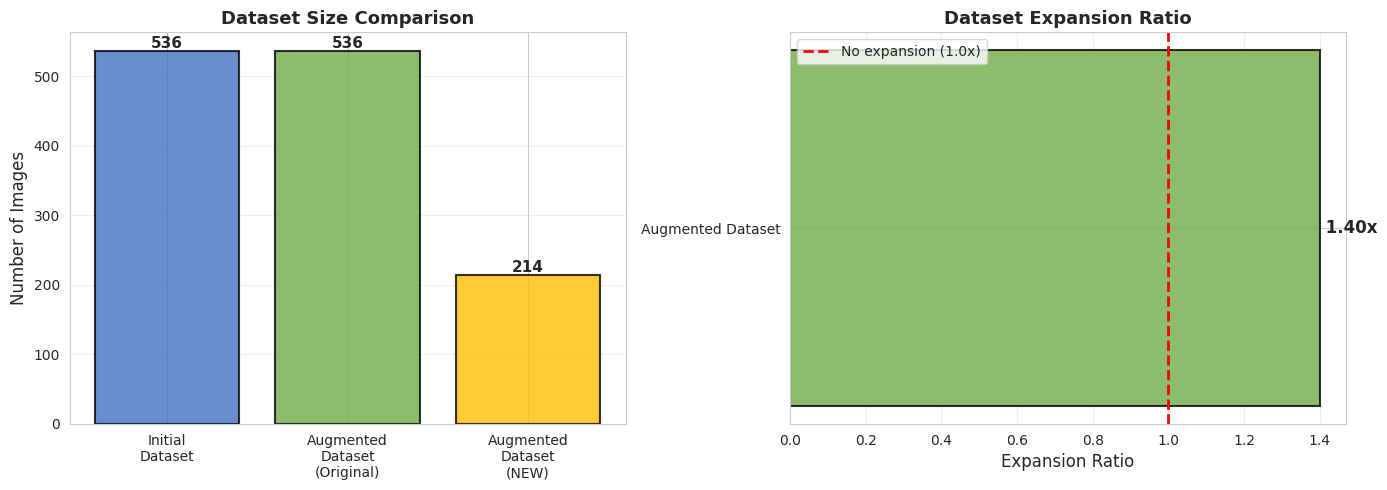

✓ Dataset comparison visualization created


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Initial vs Augmented Dataset Comparison
ax = axes[0]
categories = ['Initial\nDataset', 'Augmented\nDataset\n(Original)', 'Augmented\nDataset\n(NEW)']
counts = [initial_counts['total'], augmented_counts['original'], augmented_counts['augmented']]
colors = ['#4472C4', '#70AD47', '#FFC000']

bars = ax.bar(categories, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Dataset Size Comparison', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Expansion Ratio
ax = axes[1]
ax.barh(['Augmented Dataset'], [augmented_counts['total'] / initial_counts['total']], 
        color='#70AD47', alpha=0.8, edgecolor='black', linewidth=1.5, height=0.5)
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='No expansion (1.0x)')
ax.set_xlabel('Expansion Ratio', fontsize=12)
ax.set_title('Dataset Expansion Ratio', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

ratio = augmented_counts['total'] / initial_counts['total']
ax.text(ratio, 0, f' {ratio:.2f}x', va='center', ha='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Dataset comparison visualization created")


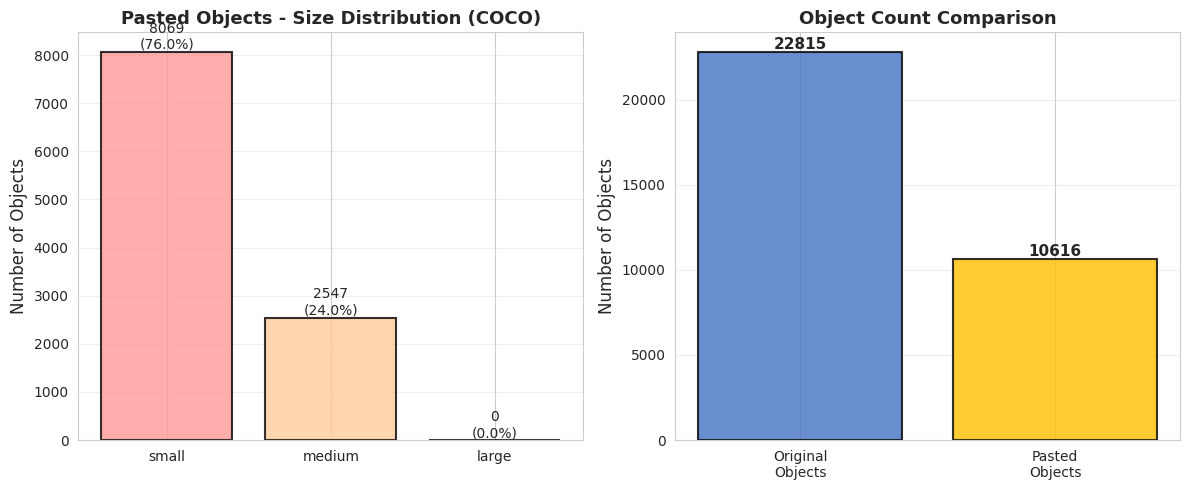

✓ Object analysis visualization created


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if len(objects_df) > 0:
    pasted = objects_df[objects_df['is_augmented'] == True]
    original = objects_df[objects_df['is_augmented'] == False]
    
    # Plot 1: Pasted objects size distribution
    if len(pasted) > 0:
        size_counts = pasted['size_category'].value_counts()
        size_order = ['small', 'medium', 'large']
        size_counts_ordered = [size_counts.get(cat, 0) for cat in size_order]
        
        ax = axes[0]
        colors = ['#ff9999', '#ffcc99', '#99cc99']
        bars = ax.bar(size_order, size_counts_ordered, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
        
        ax.set_ylabel('Number of Objects', fontsize=12)
        ax.set_title('Pasted Objects - Size Distribution (COCO)', fontsize=13, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        for bar in bars:
            height = bar.get_height()
            pct = height/len(pasted)*100
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
    
    # Plot 2: Original vs Pasted object count
    ax = axes[1]
    data = [len(original), len(pasted)]
    labels = ['Original\nObjects', 'Pasted\nObjects']
    colors_comp = ['#4472C4', '#FFC000']
    
    bars = ax.bar(labels, data, color=colors_comp, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Number of Objects', fontsize=12)
    ax.set_title('Object Count Comparison', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    for bar, count in zip(bars, data):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Object analysis visualization created")
